# Time-varying Neural Dynamics

**This project is the final project for Brown APMA 1360 Applied Dynamical Systems**

This is the final report for generating required figures.

## Import

In [1]:
# %matplotlib widget
import importlib

import numpy as np
import jPCA
from jPCA.jPCA import JPCA
import matplotlib.pyplot as plt
from jPCA.util import load_churchland_data, plot_projections, preprocess
from jPCA.regression import skew_sym_regress
from utils import *

## Read Data

We are going to use the example data provided by the Churchland group used for original jPCA paper where a monkey performed delayed reaching tasks. The data read in is 

$$X \in \reals^{C \times T \times N}$$

where N is the number of neurons (218), and C is the number of conditions.

In [2]:
path = "exampleData.mat"
data, times = load_churchland_data(path)
times_full_axis = list(times)  # full −50…550 ms axis for full-epoch section below

print(f"Number of conditions: {len(data)}")
print(f"Number of neurons: {data[0].shape[1]}")
print(f"Number of time points: {data[0].shape[0]}")

print(f"Time range: {times[0]} to {times[-1]} ms.")
print(f"Sampling rate: {1 / np.mean(np.diff(times)/1000):.2f} Hz.")

Number of conditions: 108
Number of neurons: 218
Number of time points: 61
Time range: -50 to 550 ms.
Sampling rate: 100.00 Hz.


The data loaded is a list of conditions. There are 108 conditions in total, and for each condition, there is an numpy array of shape `(61, 218)`

Average firing rate across conditions: (61, 218)


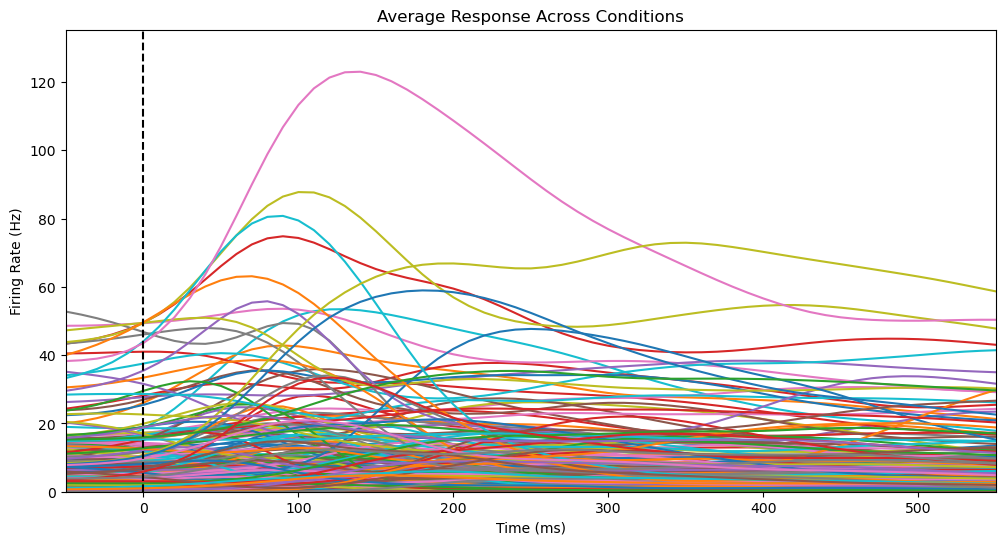

In [3]:
# Plot some data
average_data = np.mean(data, axis=0)
print(f"Average firing rate across conditions: {average_data.shape}")

# Firing rates of each channel
plt.figure(figsize=(12, 6))
plt.plot(times, average_data)
plt.title("Average Response Across Conditions")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
plt.ylim(0, np.max(average_data) * 1.1)
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

## Preprocessing

Preprocessing includes soft normalization, mean subtraction, and PCA. Here we just utilize the preprocessing method in the toolbox.

Data shape after preprocessing: (108, 21, 6)


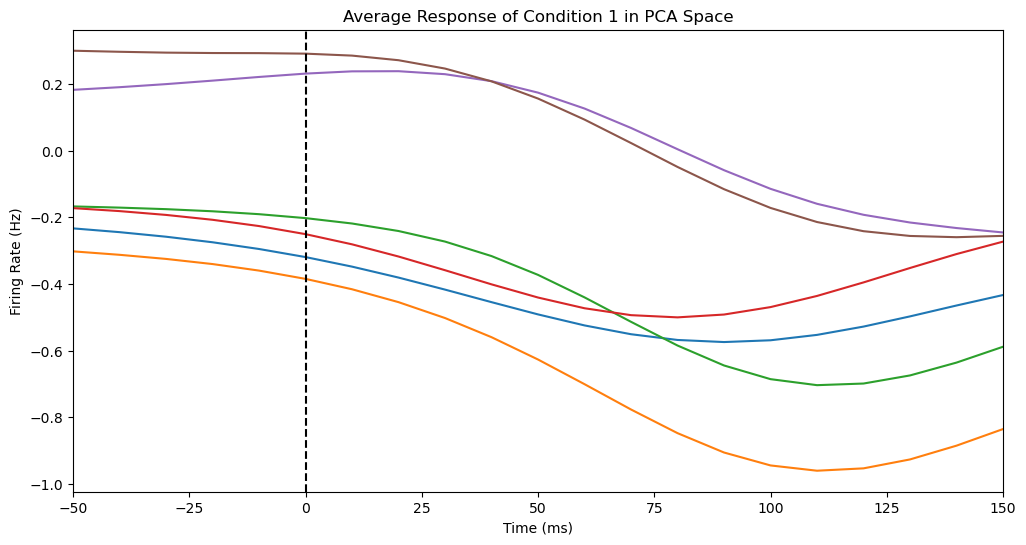

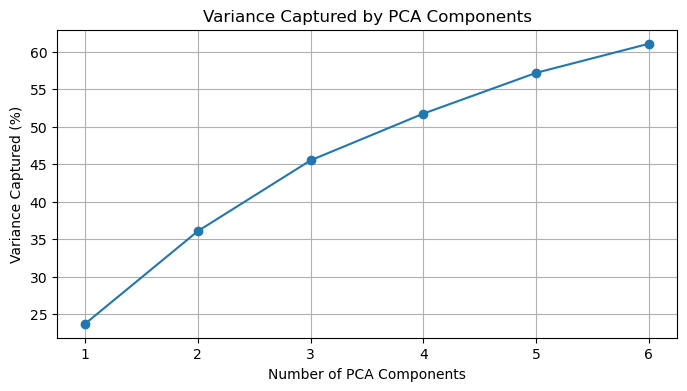

In [4]:
data_list, full_data_var, pca_variance_captured = preprocess(data, times, tstart=-50, tend=150)
times = [t for t in times if -50 <= t <= 150]
data_reduced = np.stack(data_list, axis=0)
print(f"Data shape after preprocessing: {data_reduced.shape}")

plt.figure(figsize=(12, 6))
plt.plot(times, data_list[0])
plt.title("Average Response of Condition 1 in PCA Space")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

ratio_captured = pca_variance_captured / full_data_var
ratio_captured_cumsum = np.cumsum(ratio_captured)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(ratio_captured_cumsum) + 1), ratio_captured_cumsum * 100, marker='o')
plt.title("Variance Captured by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Variance Captured (%)")
plt.grid()
plt.show()


## Dynamics in PCA space

We can now visualize the neural dynamics in the PCA space. We are only ploting the top 3 PCs. Note that here's the entire trial from -50 ms to 550 ms.

### Plot the trajectories

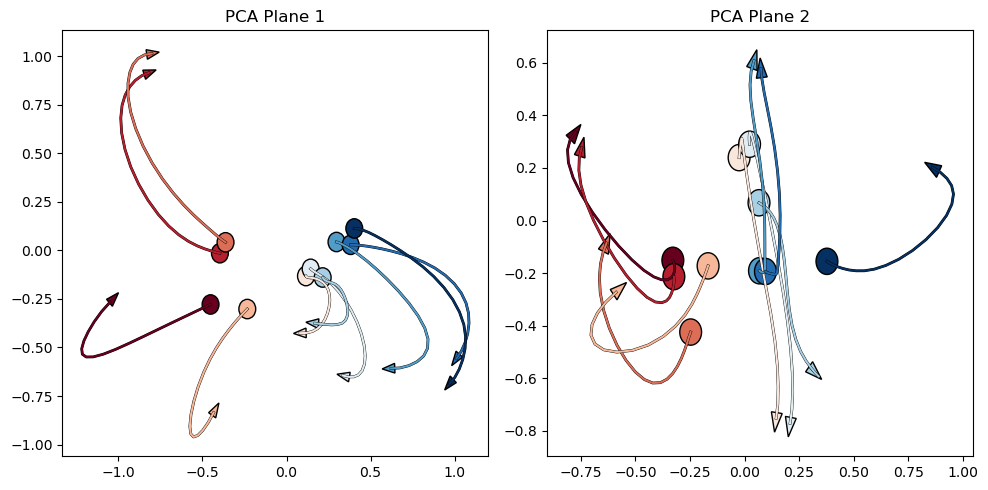

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_projections(data_list[0:10], axis=axes[0], x_idx=0, y_idx=1)
plot_projections(data_list[0:10], axis=axes[1], x_idx=2, y_idx=3)

axes[0].set_title("PCA Plane 1")
axes[1].set_title("PCA Plane 2")
plt.tight_layout()
plt.show()

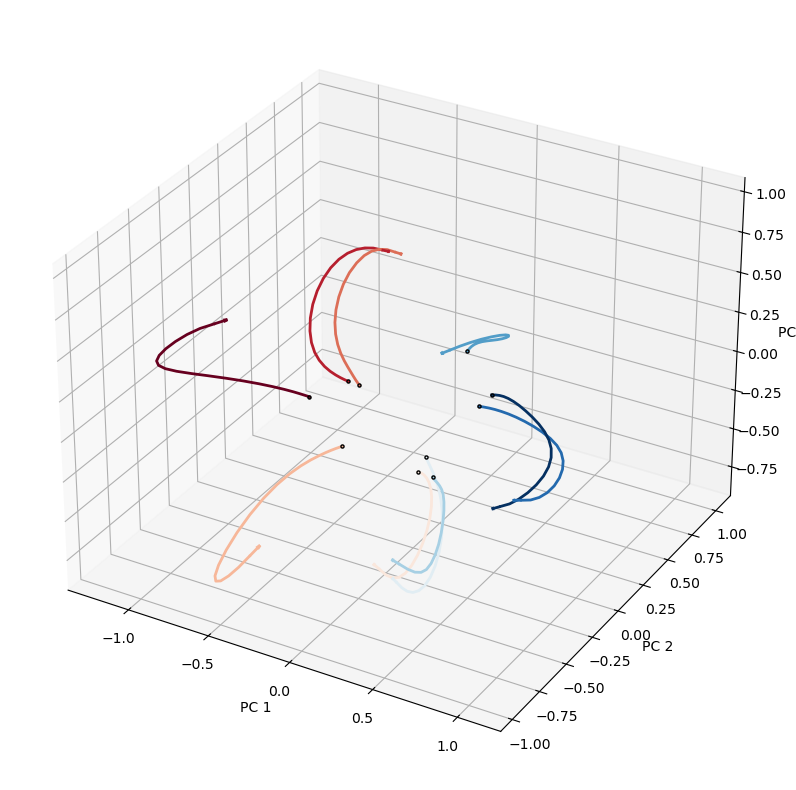

In [6]:
fig = plt.figure(figsize=(8, 8))
axis = fig.add_subplot(111, projection='3d')
plot_3d_projections(data_list[0:10], axis=axis, x_idx=0, y_idx=1, z_idx=2)

axis.set_xlabel('PC 1')
axis.set_ylabel('PC 2')
axis.set_zlabel('PC 3')
plt.tight_layout()
plt.show()

### Fit the dynamics

Try the unconstraint neural dynamics in the PCA space first. We assume the dynamics to be:

$$\dot{x} = Mx$$

where $\dot{x} = x(t+1) - x(t)$. Therefore, 

$$M = \argmin ||\dot{X} - MX||_F^2$$

Shape of X for Dynamics: (2160, 6)
Shape of X_dot for Dynamics: (2160, 6)


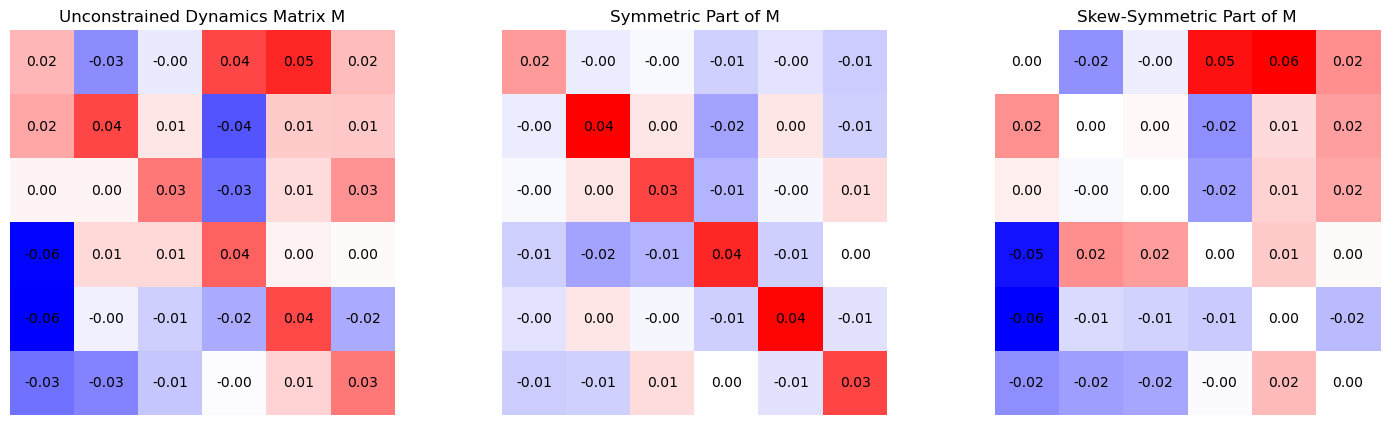

In [7]:
X = np.concatenate([x[:-1] for x in data_list])
print(f"Shape of X for Dynamics: {X.shape}")
X_dot = np.concatenate([np.diff(x, axis=0) for x in data_list])
print(f"Shape of X_dot for Dynamics: {X_dot.shape}")

# HACK: This might not be the best way to handle the last time point
# but this is how they did it in the original jPCA code, so we'll follow that for now.

# Unconstrained Dynamics
M = np.linalg.lstsq(X, X_dot, rcond=None)[0]

# Decomposing M into symmetric and skew-symmetric parts
M_symmetric = 0.5 * (M + M.T)
M_skew = 0.5 * (M - M.T)

# Plot the matrix M as a heatmap
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(M, cmap='bwr', vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        plt.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Unconstrained Dynamics Matrix M")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(M_symmetric, cmap='bwr', vmin=-np.max(np.abs(M_symmetric)), vmax=np.max(np.abs(M_symmetric)))
for i in range(M_symmetric.shape[0]):
    for j in range(M_symmetric.shape[1]):
        plt.text(j, i, f"{M_symmetric[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Symmetric Part of M")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(M_skew, cmap='bwr', vmin=-np.max(np.abs(M_skew)), vmax=np.max(np.abs(M_skew)))
for i in range(M_skew.shape[0]):
    for j in range(M_skew.shape[1]):
        plt.text(j, i, f"{M_skew[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Skew-Symmetric Part of M")
plt.axis('off')
plt.show()

## Dynamics in jPCA planes

### Comparasion between the two skew methods

One way is to use

$$M_{skew} = \frac{M - M^T}{2}$$

and the other way is to use the optimization method they used in jPCA package.

From the matrices we plot, the two methods don't have much difference.

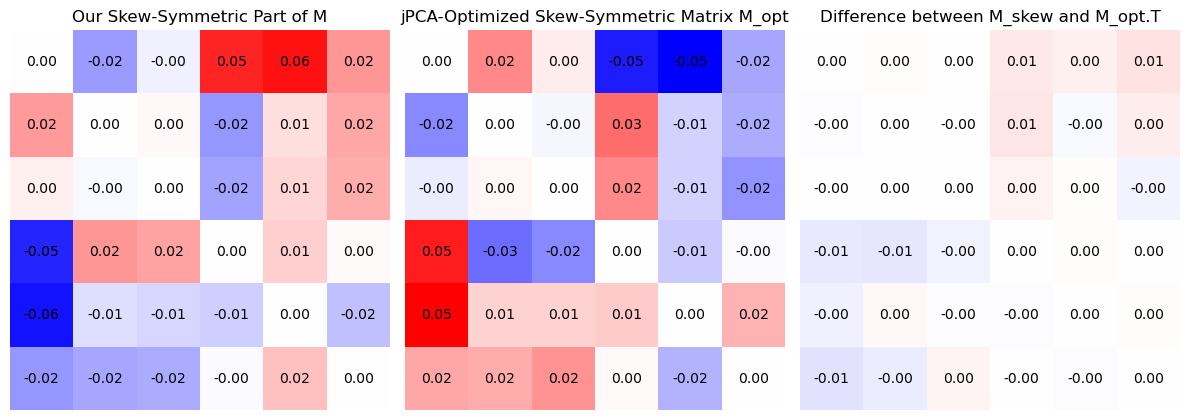

In [8]:
# jPCA methods
M_opt = skew_sym_regress(X, X_dot)

# Plot the comparasion
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(M_skew, cmap='bwr', vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
for i in range(M_skew.shape[0]):
    for j in range(M_skew.shape[1]):
        plt.text(j, i, f"{M_skew[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Our Skew-Symmetric Part of M")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(M_opt, cmap='bwr', vmin=-np.max(np.abs(M_opt)), vmax=np.max(np.abs(M_opt)))
for i in range(M_opt.shape[0]):
    for j in range(M_opt.shape[1]):
        plt.text(j, i, f"{M_opt[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("jPCA-Optimized Skew-Symmetric Matrix M_opt")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(M_skew - M_opt.T, cmap='bwr', vmin=-np.max(np.abs(M_skew)), vmax=np.max(np.abs(M_skew)))
for i in range(M_skew.shape[0]):
    for j in range(M_skew.shape[1]):
        plt.text(j, i, f"{(M_skew[i, j] - M_opt.T[i, j]):.2f}", ha='center', va='center', color='black')
plt.title("Difference between M_skew and M_opt.T")
plt.axis('off')
plt.tight_layout()
plt.show()

### Find the jPCA plane

We start with the eigendecomposition. The skew-symmetric matrix will have 6 eigenvalues forming 3 conjugate imaginary value pairs

$$\pm aj, \pm bj, \pm cj \text{ s.t. } a>b>c$$

for each pair, the eigenvectors will be

$$v_{1,2} = \alpha \pm \beta j$$

and the first jPCA plane we select will be:

$$
\begin{bmatrix}
    jPCA_1 \\
    jPCA_2
\end{bmatrix}
=
\begin{bmatrix}
    v_1 + v_2 \\
    v_1 - v_2
\end{bmatrix}
$$

In [9]:
# 5. eigen decompose (PCA space: V is D×D)
eigenvalues, V = np.linalg.eig(M_skew)
order = np.argsort(np.abs(np.imag(eigenvalues)), kind="stable")[::-1]
eigenvalues = eigenvalues[order]
V = V[:, order]
D = M_skew.shape[0]
print(f"Eigenvalues of M_skew (sorted by imaginary part): \n{eigenvalues}")


Eigenvalues of M_skew (sorted by imaginary part): 
[ 2.09672300e-18-0.08624802j  2.09672300e-18+0.08624802j
 -3.03578708e-18-0.04559005j -3.03578708e-18+0.04559005j
 -5.21510562e-19-0.00222143j -5.21510562e-19+0.00222143j]


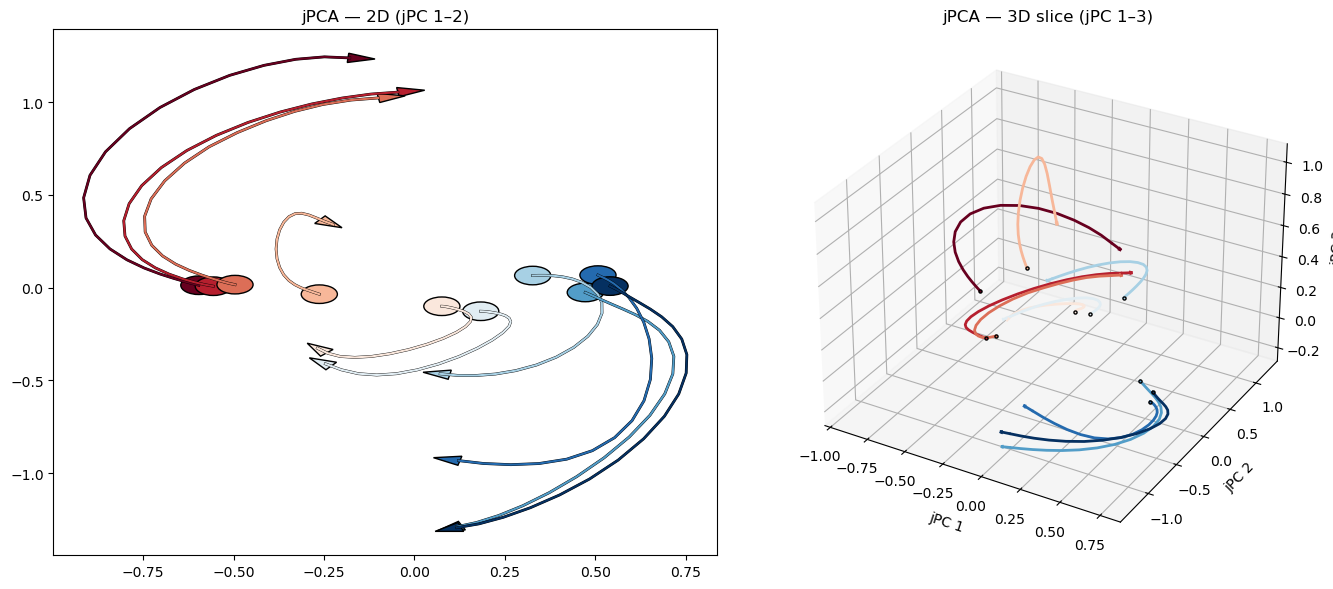

In [10]:
# 6. jPCA planes — full toolbox basis (num_jpcs>=3 for a 3D slice)
num_jpcs = 6
jp_scratch = JPCA(num_jpcs=num_jpcs)
jp_scratch.jpcs = jp_scratch._calculate_jpcs(M_skew)
jp_scratch.align_jpcs(data_list)
w_plot = jp_scratch.jpcs

z = X @ w_plot

projected_manual = [trial @ w_plot for trial in data_list]
fig = plt.figure(figsize=(14, 6))
ax2d = fig.add_subplot(1, 2, 1)
plot_projections(projected_manual[:10], axis=ax2d, x_idx=0, y_idx=1)
ax2d.set_title("jPCA — 2D (jPC 1–2)")
ax3d = fig.add_subplot(1, 2, 2, projection="3d")
plot_3d_projections(projected_manual[:10], axis=ax3d, x_idx=0, y_idx=1, z_idx=2)
ax3d.set_xlabel("jPC 1")
ax3d.set_ylabel("jPC 2")
ax3d.set_zlabel("jPC 3")
ax3d.set_title("jPCA — 3D slice (jPC 1–3)")
plt.tight_layout()
plt.show()


### Sliding windows — restricted epoch (−50 … 150 ms)



### Full epoch (−50 … 550 ms) — sliding-window \(M_{\mathrm{skew}}(t)\)


In [11]:
# full-span PCA + sliding fits 
t0_full = int(times_full_axis[0])
t1_full = int(times_full_axis[-1])
data_list_full, full_data_var_long, pca_variance_captured_full = preprocess(
    data, times_full_axis, tstart=t0_full, tend=t1_full
)
sl = times_full_axis.index(t0_full)
su = times_full_axis.index(t1_full)
times_full = times_full_axis[sl : su + 1]

WINDOW_LEN_BINS_FULL = 10  # match restricted section or tune independently
STEP_BINS_FULL = 1
n_times_f = data_list_full[0].shape[0]
half_f = WINDOW_LEN_BINS_FULL // 2

# trajectory_full_lstq = []
trajectory_full_skew_sym = []

for center_bin in range(half_f, n_times_f - half_f, STEP_BINS_FULL):
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, n_times_f)
    X_w, Xdot_w = stack_XY_in_window(data_list_full, bins)
    # M_ls = np.linalg.lstsq(X_w, Xdot_w, rcond=None)[0]
    # M_skew_lstq = 0.5 * (M_ls - M_ls.T)
    # trajectory_full_lstq.append((center_bin, times_full[center_bin], M_skew_lstq))
    M_skew_symfit = skew_sym_regress(X_w, Xdot_w)
    trajectory_full_skew_sym.append((center_bin, times_full[center_bin], M_skew_symfit))

trajectory_full = trajectory_full_skew_sym  # alias for older text

print(f"full epoch: T={n_times_f} bins, {len(trajectory_full_skew_sym)} window fits (skew_sym_regress)")

M_skew_list = [Msk for _, _, Msk in trajectory_full_skew_sym]

print(len(M_skew_list), M_skew_list[0].shape)

full epoch: T=61 bins, 51 window fits (skew_sym_regress)
51 (6, 6)


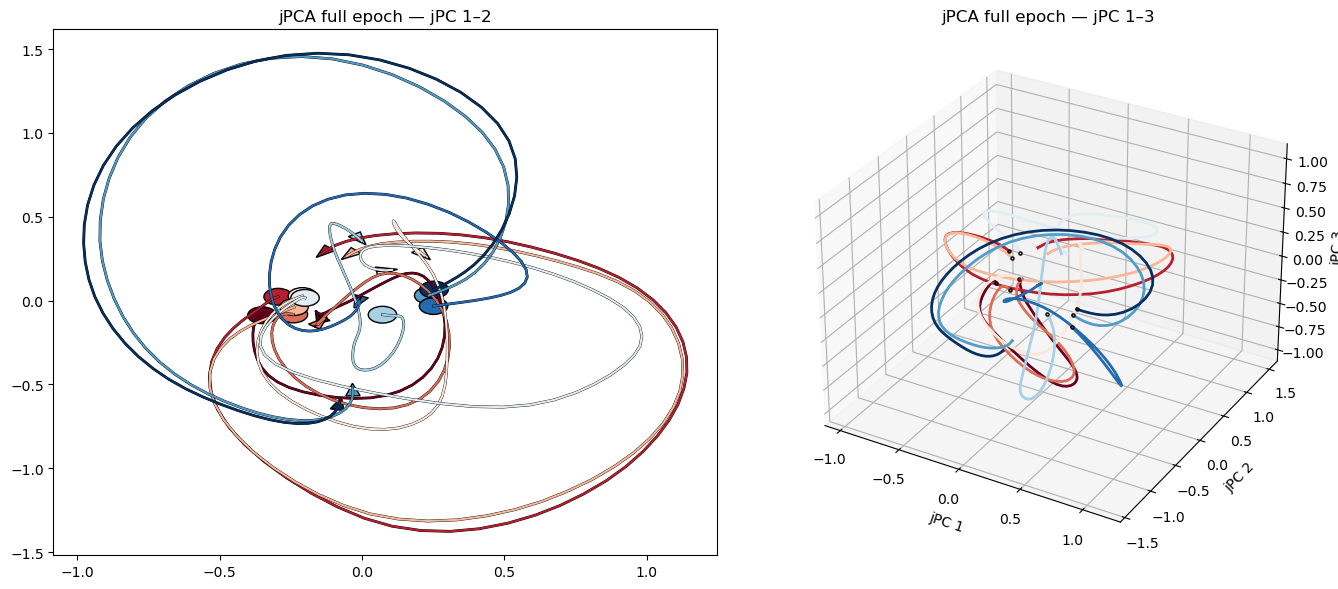

In [12]:
# plot jPCA trajectories for the full time length available in the data
Xgf = np.concatenate([x[:-1] for x in data_list_full])
Xdgf = np.concatenate([np.diff(x, axis=0) for x in data_list_full])
M_full = skew_sym_regress(Xgf, Xdgf)

num_jpcs = 6
jp_full = JPCA(num_jpcs=num_jpcs)
jp_full.jpcs = jp_full._calculate_jpcs(M_full)
jp_full.align_jpcs(data_list_full)
w = jp_full.jpcs

projected_full = [trial @ w for trial in data_list_full]

fig = plt.figure(figsize=(14, 6))
ax2d = fig.add_subplot(1, 2, 1)
plot_projections(projected_full[:10], axis=ax2d, x_idx=0, y_idx=1)
ax2d.set_title("jPCA full epoch — jPC 1–2")

ax3d = fig.add_subplot(1, 2, 2, projection="3d")
plot_3d_projections(projected_full[:10], axis=ax3d, x_idx=0, y_idx=1, z_idx=2)
ax3d.set_xlabel("jPC 1")
ax3d.set_ylabel("jPC 2")
ax3d.set_zlabel("jPC 3")
ax3d.set_title("jPCA full epoch — jPC 1–3")

plt.tight_layout()
plt.show()

## Sliding-window Dynamics Analysis

#### Windowed Unconstrained Matrix

full epoch: T=61 bins, 51 window fits (lstsq unconstrained M)
51 (6, 6)


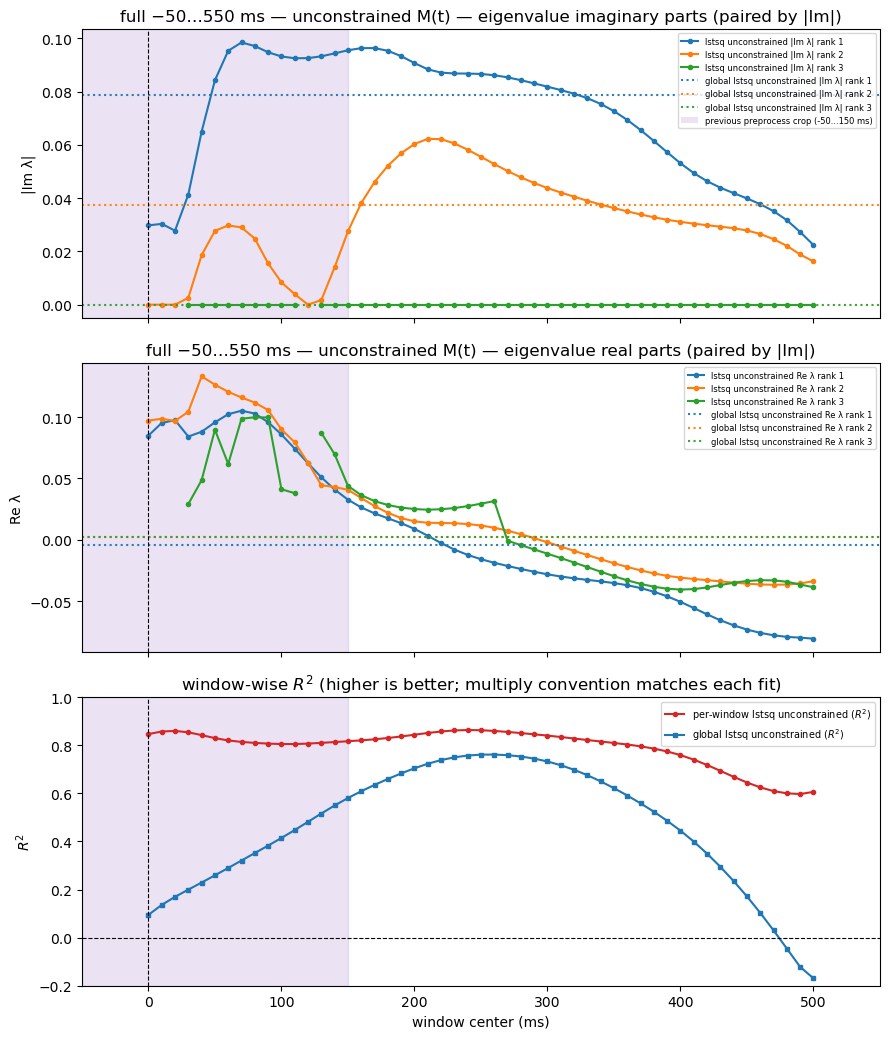

In [13]:
#Fit time varying unconstrained matrix M(t) for the full timespan

# full-span PCA + sliding fits 
t0_full = int(times_full_axis[0])
t1_full = int(times_full_axis[-1])
data_list_full, full_data_var_long, pca_variance_captured_full = preprocess(
    data, times_full_axis, tstart=t0_full, tend=t1_full
)
sl = times_full_axis.index(t0_full)
su = times_full_axis.index(t1_full)
times_full = times_full_axis[sl : su + 1]

# trajectory_full_lstq = []
trajectory_full_unconstrained = []

for center_bin in range(half_f, n_times_f - half_f, STEP_BINS_FULL):
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, n_times_f)
    X_w, Xdot_w = stack_XY_in_window(data_list_full, bins)
    # M_ls = np.linalg.lstsq(X_w, Xdot_w, rcond=None)[0]
    # M_skew_lstq = 0.5 * (M_ls - M_ls.T)
    # trajectory_full_lstq.append((center_bin, times_full[center_bin], M_skew_lstq))
    M = np.linalg.lstsq(X_w, Xdot_w, rcond=None)[0]
    trajectory_full_unconstrained.append((center_bin, times_full[center_bin], M))

trajectory_full = trajectory_full_unconstrained  # alias for older text

print(f"full epoch: T={n_times_f} bins, {len(trajectory_full_unconstrained)} window fits (lstsq unconstrained M)")

M_list = [Msk for _, _, Msk in trajectory_full_unconstrained]

print(len(M_list), M_list[0].shape)

Xgf = np.concatenate([x[:-1] for x in data_list_full])
Xdgf = np.concatenate([np.diff(x, axis=0) for x in data_list_full])
M_global_unc = np.linalg.lstsq(Xgf, Xdgf, rcond=None)[0]

diagnose_skew_trajectory(
    trajectory_full_unconstrained,
    data_list_full,
    times_full,
    WINDOW_LEN_BINS_FULL,
    title="full −50…550 ms — unconstrained M(t)",
    M_skew_global=M_global_unc,
    M_skew_global_label="global lstsq unconstrained",
    pred_rhs_transpose=False,
    primary_series_label="lstsq unconstrained",
    plot_real_part=True,
)


#### Windowed Skew-symmetric Matrix

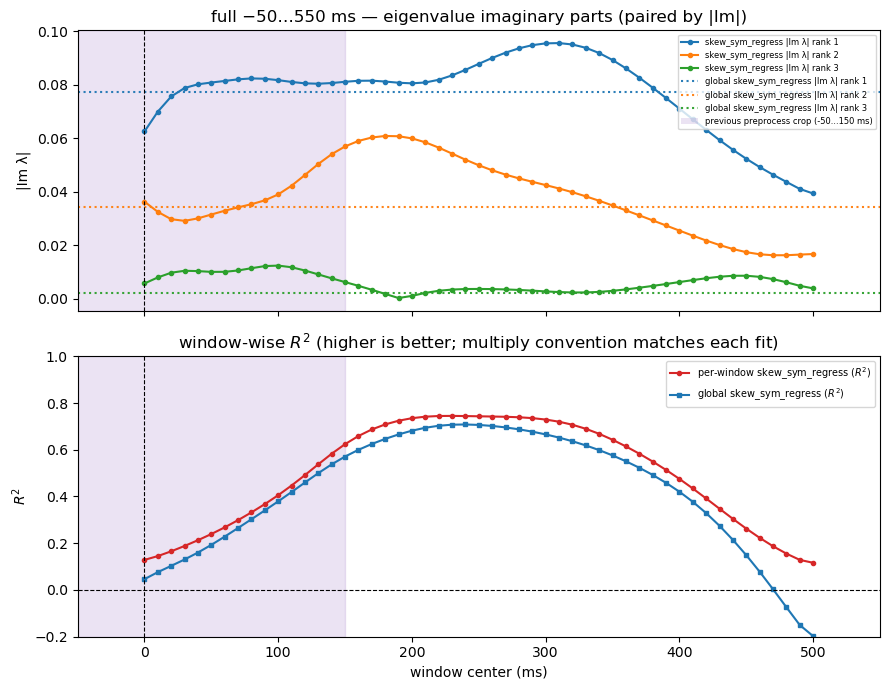

In [14]:
need = ("trajectory_full_skew_sym", "WINDOW_LEN_BINS_FULL")
if any(k not in globals() for k in need):
    print("run the full-epoch sliding-window cell first")
elif not globals().get("trajectory_full_skew_sym"):
    print("empty trajectories — rerun sliding-window cell")
else:
    Xgf = np.concatenate([x[:-1] for x in data_list_full])
    Xdgf = np.concatenate([np.diff(x, axis=0) for x in data_list_full])
    # Mga = np.linalg.lstsq(Xgf, Xdgf, rcond=None)[0]
    # M_skew_global_lstq = 0.5 * (Mga - Mga.T)
    M_skew_global_skew_sym = skew_sym_regress(Xgf, Xdgf)
    diagnose_skew_trajectory(
        trajectory_full_skew_sym,
        data_list_full,
        times_full,
        WINDOW_LEN_BINS_FULL,
        title="full −50…550 ms",
        M_skew_global=M_skew_global_skew_sym,
        M_skew_global_label="global skew_sym_regress",
        pred_rhs_transpose=True,
        primary_series_label="skew_sym_regress",
    )

#### Difference between the Two Skew-symmetric Matrices

One thing we can notice from these plots is that the skew-symmetric matrix has a different $|\text{Im }{\lambda}|$. This is because it has to compensite for the decay or expansion behavior of the dynamics. Therefore, we want to compare these two dynamics and see if when the rotational dynamic is the dominant in the system.

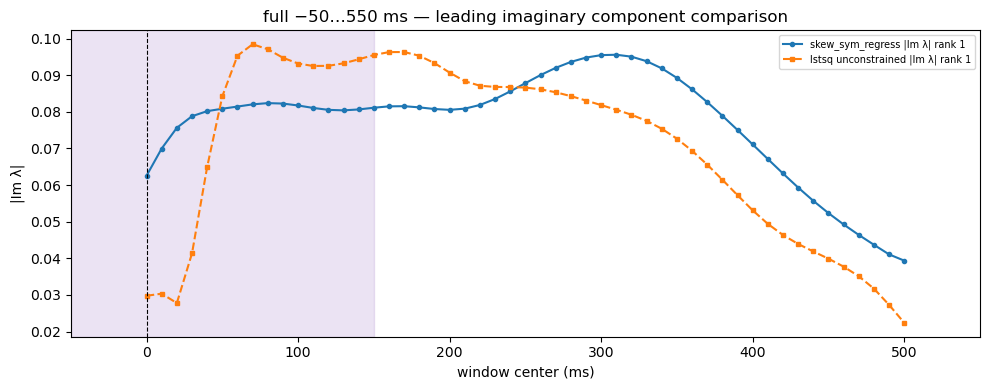

In [15]:
need = (
    "trajectory_full_skew_sym",
    "trajectory_full_unconstrained",
    "WINDOW_LEN_BINS_FULL",
    "M_skew_global_skew_sym",
    "M_global_unc",
)
if any(k not in globals() for k in need):
    print("run the full-epoch sliding-window cells first")
else:
    def _leading_imag_component(trajectory):
        centers_ms = []
        leading_im = []
        for _, center_ms, M_win in trajectory:
            w = np.linalg.eigvals(M_win)
            im_sorted = np.sort(np.unique(np.round(np.abs(np.imag(w)), 12)))[::-1]
            centers_ms.append(center_ms)
            leading_im.append(im_sorted[0] if len(im_sorted) > 0 else np.nan)
        return np.asarray(centers_ms), np.asarray(leading_im)

    centers_skew, im_skew = _leading_imag_component(trajectory_full_skew_sym)
    centers_unc, im_unc = _leading_imag_component(trajectory_full_unconstrained)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        centers_skew,
        im_skew,
        "-o",
        ms=3,
        color="C0",
        label="skew_sym_regress |Im λ| rank 1",
    )
    ax.plot(
        centers_unc,
        im_unc,
        "--s",
        ms=3,
        color="C1",
        label="lstsq unconstrained |Im λ| rank 1",
    )

    ax.axvspan(-50, 150, alpha=0.18, color="tab:purple", zorder=0)
    ax.axvline(0, color="k", ls="--", lw=0.8, zorder=2)
    ax.set_ylabel("|Im λ|")
    ax.set_xlabel("window center (ms)")
    ax.set_title("full −50…550 ms — leading imaginary component comparison")
    ax.set_xlim(-50, 550)
    ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()

## System Property Analysis

Since the phase portrait of a skew-sysmmetric matrix will only be circles. We are going to perform the analysis only on the unconstrained matrix.

### Portion of Rotational Behavior in the System

$$\frac{||M_{skew}||_F^2}{||M||_F^2}$$

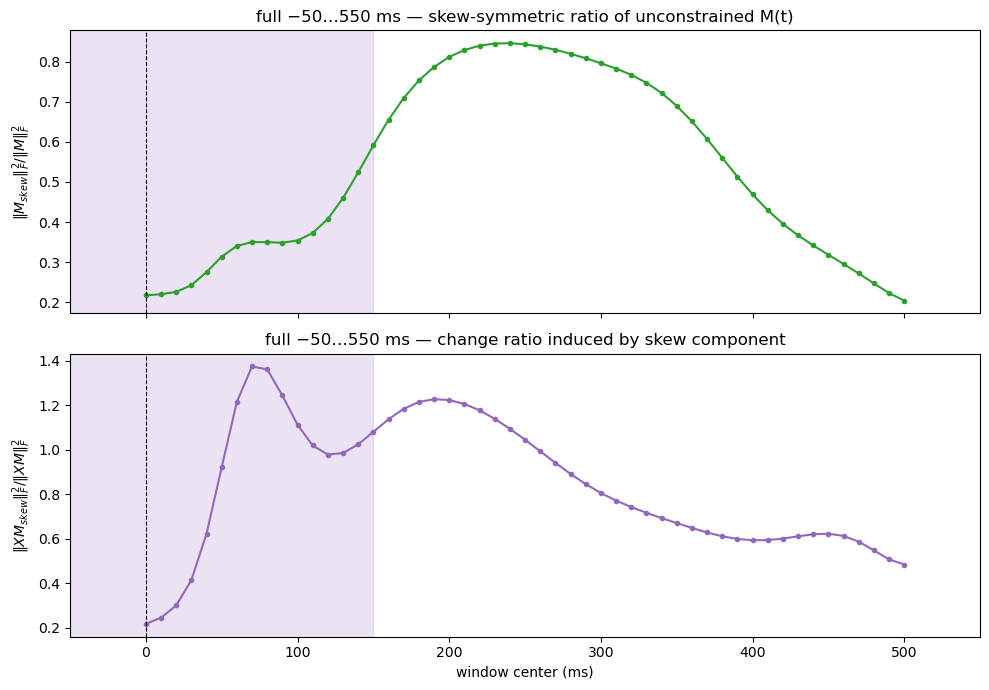

In [16]:
ratios = []
ratios_xm = []
centers_local = []

for center_bin, center_ms, M_win in trajectory_full_unconstrained:
    M_skew_win = 0.5 * (M_win - M_win.T) # Use XM for this

    # Existing ratio: matrix-level skew part over full matrix.
    den_M = np.linalg.norm(M_win, ord="fro") ** 2
    num_M = np.linalg.norm(M_skew_win, ord="fro") ** 2
    ratios.append(num_M / den_M if den_M > 0 else np.nan)

    # New ratio: induced change magnitude ratio ||X M_skew||_F^2 / ||X M||_F^2.
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, len(times_full))
    X_w, _ = stack_XY_in_window(data_list_full, bins)
    XM = X_w @ M_win
    XM_skew = X_w @ M_skew_win
    den_XM = np.linalg.norm(XM, ord="fro") ** 2
    num_XM = np.linalg.norm(XM_skew, ord="fro") ** 2
    ratios_xm.append(num_XM / den_XM if den_XM > 0 else np.nan)

    centers_local.append(center_ms)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(centers_local, ratios, "-o", ms=3, color="C2")
axes[0].axvspan(-50, 150, alpha=0.18, color="tab:purple", zorder=0)
axes[0].axvline(0, color="k", ls="--", lw=0.8, zorder=2)
axes[0].set_ylabel(r"$\|M_{skew}\|_F^2 / \|M\|_F^2$")
axes[0].set_title("full −50…550 ms — skew-symmetric ratio of unconstrained M(t)")
axes[0].set_xlim(-50, 550)

axes[1].plot(centers_local, ratios_xm, "-o", ms=3, color="C4")
axes[1].axvspan(-50, 150, alpha=0.18, color="tab:purple", zorder=0)
axes[1].axvline(0, color="k", ls="--", lw=0.8, zorder=2)
axes[1].set_xlabel("window center (ms)")
axes[1].set_ylabel(r"$\|X M_{skew}\|_F^2 / \|X M\|_F^2$")
axes[1].set_title("full −50…550 ms — change ratio induced by skew component")
axes[1].set_xlim(-50, 550)

plt.tight_layout()
plt.show()

$\frac{||M_{skew}||_F^2}{||M||_F^2}$ shows how large the rotational behavior ratio is in the system.

$\frac{||XM_{skew}||_F^2}{||XM||_F^2}$ shows the magnitude ratio of the rotational dynamics to the entire dynamics. If the ratio is over 1, it means that the rotation and the symmetric behavior are moving to the different directions.

### Contraction / Expansion

From the unconstrained plot we can observe that the real part of the eigenvalues moved from positive value to negative value. So the system is first unstable (expansion) and became stabe (contraction) over time. The phase portrait should be unstable spiral to stable spiral.

## Fixed Points in Affine System

Our old method to estimate the system is to build a dynamical system following the equation:

$$\dot{x} = M x$$

without any bias term. Therefore, the only fixed point is at the origin. Now we are going to try to find fixed points and how it moves within the system by using a new system with a bias term:

$$\dot{x} = M x + b$$

**Note:** To actually calculate this, we need to also skip the normalization process.

In order to make the calculation stable we used a ridge regression with a regularization term. Therefore, we will be optimizing:

$$\min(||\Sigma(\dot{x} - Mx - b)||+\lambda||M||^2_F+\lambda|b|^2)$$

full epoch: T=61 bins, 51 window fits (lstsq affine M)


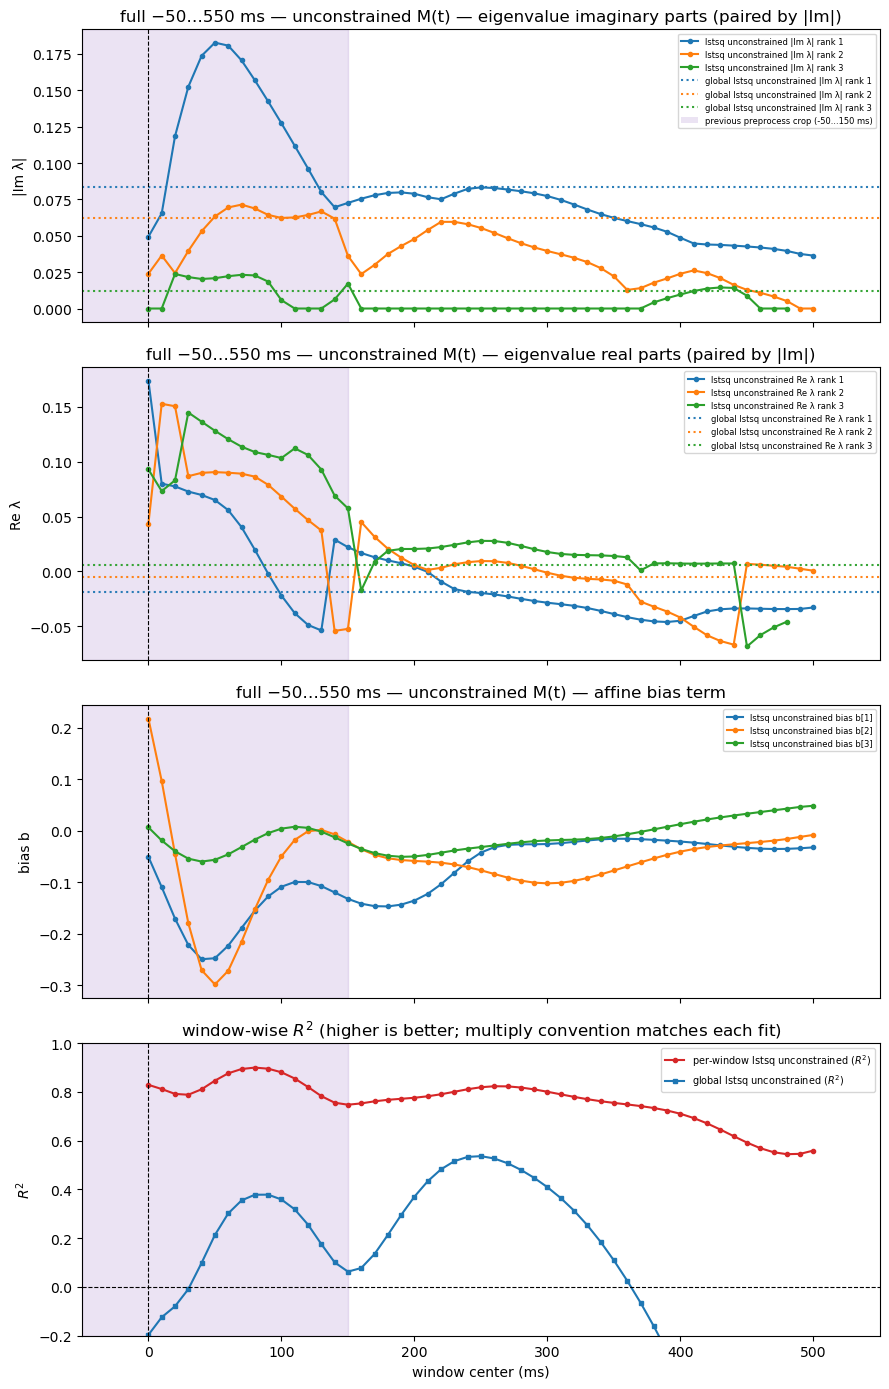

In [17]:
#Fit time varying unconstrained matrix M(t) for the full timespan

# full-span PCA + sliding fits 
t0_full = int(times_full_axis[0])
t1_full = int(times_full_axis[-1])
data_list_full, full_data_var_long, pca_variance_captured_full = preprocess(
    data, times_full_axis, tstart=t0_full, tend=t1_full, subtract_cc_mean=False
)
sl = times_full_axis.index(t0_full)
su = times_full_axis.index(t1_full)
times_full = times_full_axis[sl : su + 1]

trajectory_full_affine = []
lam = 1e-3

for center_bin in range(half_f, n_times_f - half_f, STEP_BINS_FULL):
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, n_times_f)
    X_w, Xdot_w = stack_XY_in_window(data_list_full, bins)

    # Use ridge regression to prevent overfitting
    M, b = fit_affine_ridge(X_w, Xdot_w, lam=lam, penalize_bias=False)

    trajectory_full_affine.append((center_bin, times_full[center_bin], M, b))

trajectory_full = trajectory_full_affine  # alias for older text

print(f"full epoch: T={n_times_f} bins, {len(trajectory_full_affine)} window fits (lstsq affine M)")

Xgf = np.concatenate([x[:-1] for x in data_list_full])
Xdgf = np.concatenate([np.diff(x, axis=0) for x in data_list_full])
M_global_unc = np.linalg.lstsq(Xgf, Xdgf, rcond=None)[0]

diagnose_skew_trajectory(
    trajectory_full_affine,
    data_list_full,
    times_full,
    WINDOW_LEN_BINS_FULL,
    title="full −50…550 ms — unconstrained M(t)",
    M_skew_global=M_global_unc,
    M_skew_global_label="global lstsq unconstrained",
    pred_rhs_transpose=False,
    primary_series_label="lstsq unconstrained",
    plot_real_part=True,
)

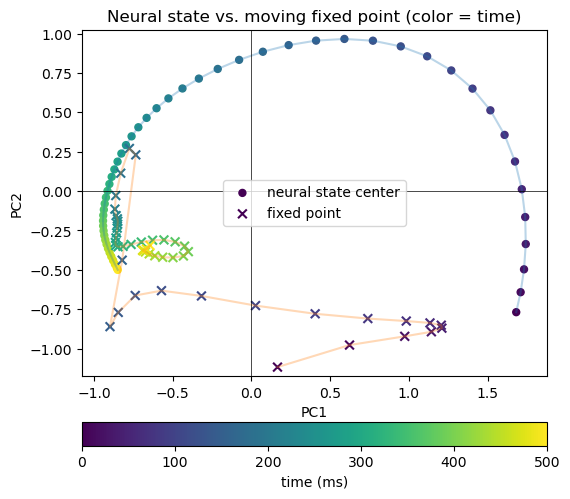

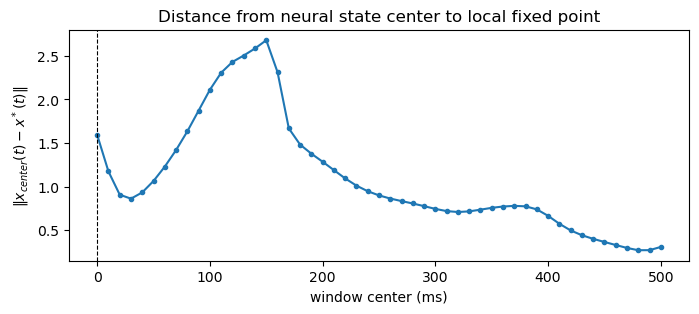

In [18]:
# Fixed points
fixed_points = []
neural_centers = []

for center_bin, center_ms, M, b in trajectory_full_affine:
    # Fixed point in the PCA / latent space
    x_star = fixed_point_damped(M, b, eps=lam)

    # Neural state position at this time window:
    # use the average state across all conditions and bins in this window
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, len(times_full))
    X_w, Xdot_w = stack_XY_in_window(data_list_full, bins)

    x_center = X_w.mean(axis=0)

    fixed_points.append((center_ms, x_star))
    neural_centers.append((center_ms, x_center))

times_fp = np.array([t for t, _ in fixed_points])
X_star = np.vstack([x for _, x in fixed_points])
X_center = np.vstack([x for _, x in neural_centers])

plt.figure(figsize=(6, 6))

# Use the same colormap
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=times_fp.min(), vmax=times_fp.max())

# Trajectory
plt.plot(X_center[:, 0], X_center[:, 1], color="C0", alpha=0.3)
plt.plot(X_star[:, 0], X_star[:, 1], color="C1", alpha=0.3)

# Scatter
sc = plt.scatter(
    X_center[:, 0], X_center[:, 1],
    c=times_fp, cmap=cmap, norm=norm,
    s=25, label="neural state center"
)

plt.scatter(
    X_star[:, 0], X_star[:, 1],
    c=times_fp, cmap=cmap, norm=norm,
    s=40, marker='x', label="fixed point"
)

cbar = plt.colorbar(sc, orientation='horizontal', pad=0.1)
cbar.set_label("time (ms)")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural state vs. moving fixed point (color = time)")
plt.legend()
plt.axis("equal")

plt.show()

dist_to_fp = np.linalg.norm(X_center - X_star, axis=1)

plt.figure(figsize=(8, 3))
plt.plot(times_fp, dist_to_fp, "-o", ms=3)
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlabel("window center (ms)")
plt.ylabel(r"$\|x_{center}(t)-x^*(t)\|$")
plt.title("Distance from neural state center to local fixed point")
plt.show()

This is a really nice plot! We can also learn from the real part of the eigenvalues that the system is first unstable and gradually became stable, which is also obvious from our plots shown above.